# ch227 — Gradient-Based Learning

Everything in modern machine learning depends on one idea: if you can compute the gradient of a loss function with respect to model parameters, you can update those parameters to reduce the loss.

This chapter synthesises: gradients *(ch209)*, backpropagation *(ch216)*, and gradient descent *(ch212)* into a coherent picture of how learning works.

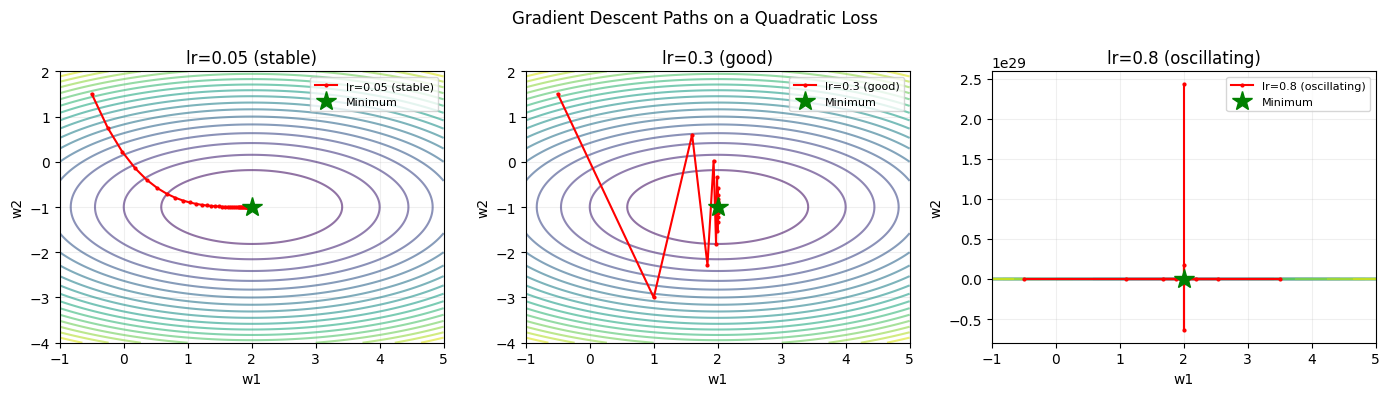

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Gradient descent on a 2D loss surface ─────────────────────────────────
def loss(w1, w2):
    return (w1 - 2)**2 + 3*(w2 + 1)**2

def grad_loss(w1, w2):
    return 2*(w1 - 2), 6*(w2 + 1)

# Run gradient descent with different learning rates
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

w1_grid = np.linspace(-1, 5, 200)
w2_grid = np.linspace(-4, 2, 200)
W1, W2 = np.meshgrid(w1_grid, w2_grid)
Z = loss(W1, W2)

for ax, lr, title in zip(axes,
        [0.05, 0.3, 0.8],
        ['lr=0.05 (stable)', 'lr=0.3 (good)', 'lr=0.8 (oscillating)']):
    ax.contour(W1, W2, Z, levels=20, cmap='viridis', alpha=0.6)
    w = np.array([-0.5, 1.5])
    path = [w.copy()]
    for _ in range(50):
        g = np.array(grad_loss(*w))
        w = w - lr * g
        path.append(w.copy())
    path = np.array(path)
    ax.plot(path[:, 0], path[:, 1], 'r.-', ms=4, lw=1.5, label=title)
    ax.plot(2, -1, 'g*', ms=15, label='Minimum')
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(True, alpha=0.2)
    ax.set_xlabel('w1'); ax.set_ylabel('w2')

plt.suptitle('Gradient Descent Paths on a Quadratic Loss')
plt.tight_layout(); plt.savefig('ch227_gd_paths.png', dpi=100); plt.show()


## Variants of Gradient Descent

Pure gradient descent (GD) is rarely used in practice. The three main variants are:

| Variant | Update uses | Batch size |
|---|---|---|
| GD (batch) | All data | Full dataset |
| SGD (stochastic) | One sample | 1 |
| Mini-batch SGD | Small subset | 32–256 typical |

Batch GD: final w=2.9284, b=2.0037, loss=0.2209
Mini-batch (16): final w=2.9406, b=2.1038, loss=0.2308
SGD: final w=3.3243, b=2.0464, loss=0.3489


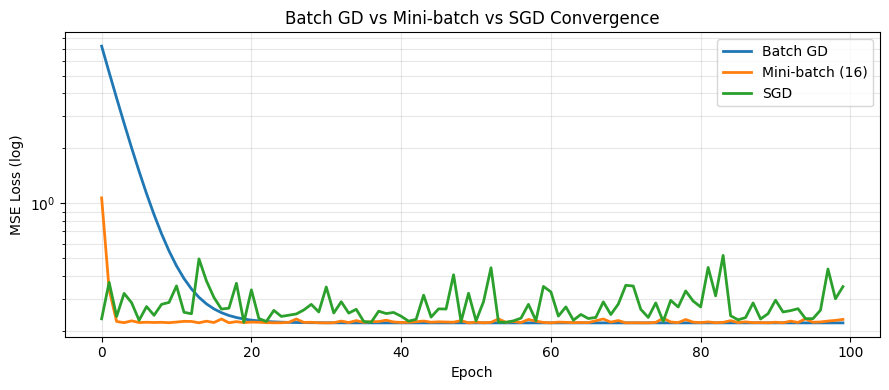

In [2]:
np.random.seed(42)

# Synthetic regression problem: y = 3x + 2 + noise
n_data = 100
X = np.random.randn(n_data)
y = 3*X + 2 + np.random.normal(0, 0.5, n_data)

def mse_loss(w, b, X, y):
    preds = w*X + b
    return np.mean((preds - y)**2)

def mse_grad(w, b, X, y):
    preds = w*X + b
    err = preds - y
    dw = 2 * np.mean(err * X)
    db = 2 * np.mean(err)
    return dw, db

# Run batch GD, SGD, mini-batch SGD
history = {}
lr = 0.1
n_epochs = 100

for name, batch_size in [('Batch GD', n_data), ('Mini-batch (16)', 16), ('SGD', 1)]:
    w, b = 0.0, 0.0
    losses = []
    for epoch in range(n_epochs):
        idx = np.random.permutation(n_data)
        for start in range(0, n_data, batch_size):
            batch = idx[start:start+batch_size]
            dw, db = mse_grad(w, b, X[batch], y[batch])
            w -= lr * dw
            b -= lr * db
        losses.append(mse_loss(w, b, X, y))
    history[name] = losses
    print(f"{name}: final w={w:.4f}, b={b:.4f}, loss={losses[-1]:.4f}")

plt.figure(figsize=(9, 4))
for name, losses in history.items():
    plt.semilogy(losses, label=name, lw=2)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss (log)')
plt.title('Batch GD vs Mini-batch vs SGD Convergence')
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('ch227_variants.png', dpi=100); plt.show()


## Momentum and Adam

Raw SGD oscillates and can get stuck in flat regions. **Momentum** accumulates past gradients to build speed. **Adam** adapts the learning rate per parameter.

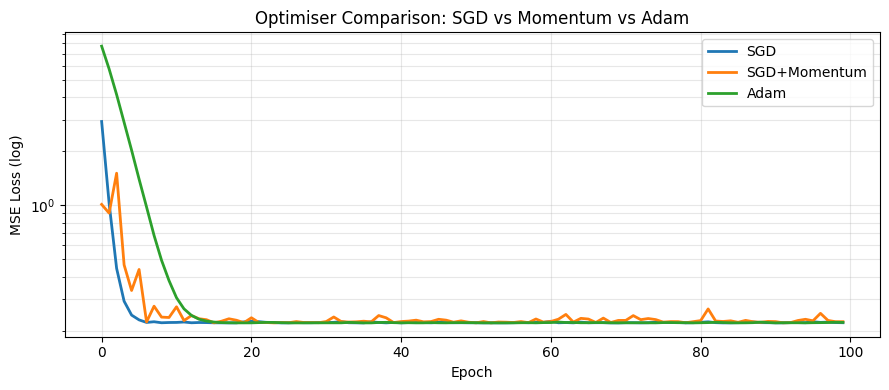

In [3]:
# Compare SGD, SGD+Momentum, and Adam on the regression problem
def run_optimizer(optimizer, n_epochs=100, lr=0.05, batch_size=16):
    w, b = 0.0, 0.0
    losses = []
    state = {}
    for epoch in range(n_epochs):
        idx = np.random.permutation(n_data)
        for start in range(0, n_data, batch_size):
            batch = idx[start:start+batch_size]
            dw, db = mse_grad(w, b, X[batch], y[batch])
            w, b = optimizer(w, b, dw, db, lr, state)
        losses.append(mse_loss(w, b, X, y))
    return losses

# SGD
def sgd(w, b, dw, db, lr, state):
    return w - lr*dw, b - lr*db

# SGD + Momentum
def momentum(w, b, dw, db, lr, state, mu=0.9):
    state.setdefault('vw', 0); state.setdefault('vb', 0)
    state['vw'] = mu*state['vw'] + dw
    state['vb'] = mu*state['vb'] + db
    return w - lr*state['vw'], b - lr*state['vb']

# Adam
def adam(w, b, dw, db, lr, state, beta1=0.9, beta2=0.999, eps=1e-8):
    state.setdefault('t', 0); state.setdefault('mw', 0); state.setdefault('mb', 0)
    state.setdefault('vw', 0); state.setdefault('vb', 0)
    state['t'] += 1
    t = state['t']
    for param, grad, m_key, v_key in [('w', dw, 'mw', 'vw'), ('b', db, 'mb', 'vb')]:
        state[m_key] = beta1*state[m_key] + (1-beta1)*grad
        state[v_key] = beta2*state[v_key] + (1-beta2)*grad**2
        m_hat = state[m_key] / (1 - beta1**t)
        v_hat = state[v_key] / (1 - beta2**t)
        if param == 'w': w -= lr * m_hat / (np.sqrt(v_hat) + eps)
        else:            b -= lr * m_hat / (np.sqrt(v_hat) + eps)
    return w, b

np.random.seed(0)
h_sgd  = run_optimizer(sgd)
np.random.seed(0)
h_mom  = run_optimizer(momentum)
np.random.seed(0)
h_adam = run_optimizer(adam)

plt.figure(figsize=(9, 4))
for h, label in [(h_sgd, 'SGD'), (h_mom, 'SGD+Momentum'), (h_adam, 'Adam')]:
    plt.semilogy(h, label=label, lw=2)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss (log)')
plt.title('Optimiser Comparison: SGD vs Momentum vs Adam')
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('ch227_optimisers.png', dpi=100); plt.show()


## Summary

| Component | Role |
|---|---|
| Loss function | What we minimise |
| Gradient | Direction of steepest ascent — step in opposite direction |
| Backpropagation | How we compute the gradient efficiently |
| Learning rate | Step size — too large = diverge, too small = slow |
| Adam | Adaptive per-parameter learning rates with momentum |

**Forward reference:** ch228 — Project: Gradient Descent Visualizer builds an interactive tool to explore these dynamics. ch229 trains a full linear regression model using these techniques from scratch.